# Regularization

When we explored Multiple Linear Regression, we tried to select features by inspecting correlations between a feature and the target as well as between features. But how did we know if we were using the right features and the right number of features? We didn't.

*Regularization* is a tool for automatically emphasizing the features that are informative as you fit the model. Recall, in fitting linear regression models, we are minimizing the mean-squared error between our predictions and the true values. The cost function has the form:

$$
J(\Theta) = \frac{1}{m}\sum_{i=0}^m(y_i - \hat{y}_i)^2
$$

Regularization adds a term to the cost function that penalizes large feature weights ($\theta_i$). Three common regularization algorithms for linear regression are:

 - [Ridge regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html):

 $$
J_{\text{ridge}}(\Theta) = \underbrace{\frac{1}{n}\sum_{i=0}^n(y_i - \hat{y}_i)^2}_{MSE(\Theta)} + \frac{\alpha}{n} \cdot \underbrace{\sum_{i=0}^p \theta_i^2}_{\text{L2 norm}}
$$

 - [Lasso regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) (Least Absolute Shrinkage and Selection Operator):

 $$
J_{\text{lasso}}(\Theta) = \underbrace{\frac{1}{n}\sum_{i=0}^n(y_i - \hat{y}_i)^2}_{MSE(\Theta)} + 2\alpha \cdot \underbrace{\sum_{i=0}^p |\theta_i|}_{\text{L1 norm}}
$$

- [Elastic Net](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) (combines Ridge and Lasso)

 $$
J_{\text{elastic net}}(\Theta) = \underbrace{\frac{1}{n}\sum_{i=0}^n(y_i - \hat{y}_i)^2}_{MSE(\Theta)} + r\cdot\underbrace{\frac{\alpha}{n} \cdot \frac{1}{2}\sum_{i=0}^p \theta_i^2}_{\text{Ridge}} + (1-r)\underbrace{\cdot2\alpha \cdot \sum_{i=0}^p |\theta_i|}_{\text{Lasso}}
$$

Where 
 - $\alpha$ is a hyper-parameter that balances how much you want to balance model simplification and model fit.
 - L2 norm is the sum of squared values of weights
 - L1 norm is the sum of the absolute values of weights
 - $r$ is a hyper-parameter in the range (0,1) that balances the amount of L2 (Ridge) and L1 (Lasso) penalty

That Ridge uses the L2-norm and Lasso uses the L1-norm can be reduced to the following observation:
 - Ridge regression will make some weights small, but not zero. This is useful if you believe many of the features contribute to the model.
 - Lasso regression will drive some weights to zero. This is useful if you believe only a few weights contribute.

 However, we generally don't know in advance how our features will contribute to the model, so best to try both and compare.


 ### Why/when to use regularization?

 - *High-dimensional data.* When number of features (p) is larger than the number of samples (n), linear regression (Ordinary Least Squares) fails.
 - *Colinear features.* Linear regression yields unstable coefficient estimates because multiple best-fit solutions exist.
 - *Model over-fitting.* Even when p<n, you may have too many parameters. That is, you're using a model more complex than the data requires. (More about that next class!)
 - *Feature selection.* You want to build a model with fewer features.

### Example: Baseball Salary Prediction (1986)

In [1]:
import pandas as pd
pd.set_option('display.precision', 2)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_df = pd.read_csv('https://raw.githubusercontent.com/acakin/hitters/refs/heads/master/hitters.csv')      
data_df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [3]:
data_df = data_df.dropna()
data_df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [4]:
cat_features = ['League', 'Division', 'NewLeague']

league_df = pd.get_dummies(data_df[cat_features], dtype = int)
league_df

,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
1,0,1,0,1,0,1
2,1,0,0,1,1,0
3,0,1,1,0,0,1
4,0,1,1,0,0,1
5,1,0,0,1,1,0
...,...,...,...,...,...,...
317,0,1,1,0,0,1
318,1,0,1,0,1,0
319,1,0,0,1,1,0
320,1,0,1,0,1,0


In [5]:


hitters_df = data_df.drop(columns = cat_features).join(league_df)
hitters_df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,PutOuts,Assists,Errors,Salary,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,...,632,43,10,475.0,0,1,0,1,0,1
2,479,130,18,66,72,76,3,1624,457,63,...,880,82,14,480.0,1,0,0,1,1,0
3,496,141,20,65,78,37,11,5628,1575,225,...,200,11,3,500.0,0,1,1,0,0,1
4,321,87,10,39,42,30,2,396,101,12,...,805,40,4,91.5,0,1,1,0,0,1
5,594,169,4,74,51,35,11,4408,1133,19,...,282,421,25,750.0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,...,325,9,3,700.0,0,1,1,0,0,1
318,492,136,5,76,50,94,12,5511,1511,39,...,313,381,20,875.0,1,0,1,0,1,0
319,475,126,3,61,43,52,6,1700,433,7,...,37,113,7,385.0,1,0,0,1,1,0
320,573,144,9,85,60,78,8,3198,857,97,...,1314,131,12,960.0,1,0,1,0,1,0


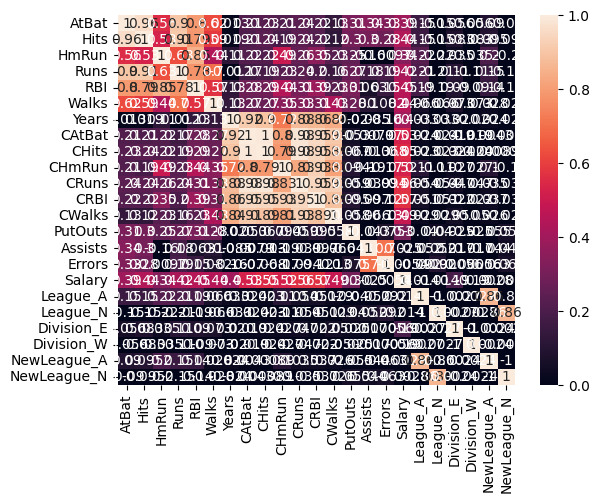

In [6]:
hitters_corr = hitters_df.corr()

sns.heatmap(hitters_corr, vmin=0, vmax=1, annot = True)
plt.show()